##### 1. Importing necessary libraries


In [ ]:
# Changes made in this model here is - Added oversampling,
# added 5 CNN layers in the noise stream
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import json
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### 2. Model architecture


In [ ]:
#SRM layer
def srm_layer(x):
    kernel = tf.constant([[[-1.0], [-1.0], [-1.0]],
                          [[-1.0], [ 8.0], [-1.0]],
                          [[-1.0], [-1.0], [-1.0]]],
                         dtype=tf.float32,
                         )
    #This matrix is used to detect edges and textures in the input image.
    #It measures the difference between a pixel and its neighbors.
    kernel = tf.repeat(kernel, repeats = 3, axis = 2)
    kernel = tf.reshape(kernel, (3, 3, 3, 1))
    x = tf.cast(x, tf.float32)
    x = tf.nn.depthwise_conv2d(x, filter=kernel, strides=[1,1,1,1], padding='SAME')
    return x

##### 3. Model

In [ ]:
# Model
def build_imdet_model(input_shape=(224, 224, 3), train_backbone=False):
    inputs = keras.Input(shape=input_shape)

    # Normalize once (shared)
    x = layers.Rescaling(1.0/255.0)(inputs)

    #RGB Stream
    rbg_backbone = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        pooling='avg')
    rbg_backbone.trainable = train_backbone
    rgb_features = rbg_backbone(x)

    #Noise stream
    x_noise = layers.Lambda(srm_layer)(x)
    x_noise = layers.BatchNormalization()(x_noise)

    n = layers.Conv2D(32, 3 , padding='same', activation='relu')(x_noise)
    n = layers.BatchNormalization()(n) # Corrected: Instantiate and apply BatchNormalization
    n = layers.MaxPooling2D()(n)

    n = layers.Conv2D(64, 3 , padding='same', activation='relu')(n)
    n = layers.BatchNormalization()(n) # Corrected: Instantiate and apply BatchNormalization
    n = layers.MaxPooling2D()(n)

    n = layers.Conv2D(128, 3 , padding='same', activation='relu')(n)
    n = layers.GlobalAveragePooling2D()(n)

    #Copy_move head
    cm = layers.Dense(128, activation='relu')(n)
    cm = layers.Dropout(0.3)(cm) # Dropout added here after test accuracy is 65.93%
    cm = layers.Dense(64, activation='relu')(cm)

    #Splicing head
    sp = layers.Dense(128, activation='relu')(n)
    sp = layers.Dropout(0.3)(sp)   # Dropout added after test accuracy is 65.93%
    sp = layers.Dense(64, activation='relu')(sp)

    noise_features = layers.Concatenate()([cm, sp])

    #Fusion
    fused_input = layers.Concatenate()([rgb_features, noise_features])
    fused_input = layers.BatchNormalization()(fused_input)

    #Attention
    att = layers.Dense(2, activation = 'softmax')(fused_input)
    att_rgb = layers.Lambda(lambda x: x[:, 0:1])(att)
    att_noise = layers.Lambda(lambda x: x[:, 1:2])(att)

    #Expand dimensions properly
    rbg_exp = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(rgb_features)
    noise_exp = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(noise_features)

    att_rgb_exp = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(att_rgb)
    att_noise_exp = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(att_noise)

    rgb_weighted = layers.Multiply()([rbg_exp, att_rgb_exp])
    noise_weighted = layers.Multiply()([noise_exp, att_noise_exp])

    fused = layers.Concatenate(axis=-1)([
        layers.Flatten()(rgb_weighted),
        layers.Flatten()(noise_weighted),
    ])

    fused = layers.Dense(128, activation='relu')(fused)
    fused = layers.BatchNormalization()(fused) # Corrected: Typo and applied BatchNormalization
    fused = layers.Dropout(0.5)(fused)

    # Added After test-accuracy is 65.93%
    fused = layers.Dense(64, activation='relu')(fused)
    fused = layers.Dropout(0.3)(fused)

    outputs = layers.Dense(3, activation='softmax')(fused)
    model = keras.Model(inputs, outputs)
    return model

#test
if __name__ == "__main__":
    model = build_imdet_model()
    model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_35 (Lambda)  │ (None, 224, 224,  │          0 │ rescaling_5[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         12 │ lambda_35[0][0]   │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 224, 224,  │        896 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_17[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 128)       │          0 │ dense_42[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 64)        │      8,256 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 64)        │      8,256 │ dropout_21[0][0]

 Total params: 24,031,569 (91.67 MB)

 Trainable params: 439,051 (1.67 MB)

 Non-trainable params: 23,592,518 (90.00 MB)

##### 4. Data Reparation
4.1 Load dataset

In [ ]:
#Load all images and labels into arrays
img_size = (224,224)
classes = ['authentic', 'copy-move', 'splicing']
X, y = [], []

# Update this path if your dataset is in a different location in Google Drive
dataset_base_path = '/content/drive/MyDrive/model_image/dataset'

for idx, cls in enumerate(classes):
    folder = os.path.join(dataset_base_path, cls)
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        img = keras.preprocessing.image.load_img(path, target_size=img_size)
        X.append(np.array(img))
        y.append(idx)

X = np.array(X, dtype=np.uint8)
y = np.array(y)

# SAVE ONCE (THIS IS KEY)
np.save('/content/drive/MyDrive/model_image/X_dataset.npy', X)
np.save('/content/drive/MyDrive/model_image/y_dataset.npy', y)

print("Dataset saved once. Next runs will load instantly.")

Dataset saved once. Next runs will load instantly.


4.2. For next runs - fast load version

In [ ]:
X = np.load('/content/drive/MyDrive/model_image/X_dataset.npy')
y = np.load('/content/drive/MyDrive/model_image/y_dataset.npy')

print("Dataset loaded instantly from disk ✔")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded instantly from disk ✔
X shape: (12614, 224, 224, 3)
y shape: (12614,)


4.3. Dataset split

In [ ]:
# One-hot encode y labels
y = tf.keras.utils.to_categorical(y, num_classes=3)

from sklearn.model_selection import train_test_split

print(" Performing dataset split (70 / 15 / 15)")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


 Performing dataset split (70 / 15 / 15)
Train: (8829, 224, 224, 3)
Val: (1892, 224, 224, 3)
Test: (1893, 224, 224, 3)


4.4 Oversampling cell

In [ ]:
# OVERSAMPLING CELL 

y_train_int = np.argmax(y_train, axis=1)

class_0 = np.where(y_train_int == 0)[0]
class_1 = np.where(y_train_int == 1)[0]
class_2 = np.where(y_train_int == 2)[0]

X0, y0 = X_train[class_0], y_train[class_0]
X1, y1 = X_train[class_1], y_train[class_1]
X2, y2 = X_train[class_2], y_train[class_2]

ds0 = tf.data.Dataset.from_tensor_slices((X0, y0)).repeat()
ds1 = tf.data.Dataset.from_tensor_slices((X1, y1)).repeat()
ds2 = tf.data.Dataset.from_tensor_slices((X2, y2)).repeat()

balanced_train = tf.data.Dataset.sample_from_datasets(
    [ds0, ds1, ds2],
    weights=[1/3, 1/3, 1/3]
)

 4.5 Data Augmentation plus tf.datapipeline


In [ ]:
#Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1), # random brightness and random contrast added after the first run
    layers.RandomContrast(0.1),  # ResNet still frozen
])

In [ ]:
# this cell allows us to use the dataset from memory
# Convert NumPy arrays (X_train, X_val, X_test, y_*) to tf.data.Dataset
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Training dataset: shuffle, batch, augment, prefetch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
train_dataset_aug = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

# Validation dataset: batch + prefetch (no augmentation)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

# Test dataset: batch + prefetch (no augmentation)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(batch_size).prefetch(buffer_size=AUTOTUNE)


4.5 class weights


In [ ]:
'''#class weight to handle class imbalance - Ablation study - freezing the weight
how the oversampling works here
class_weight = {
    0: 1.0,  # Class 0 (e.g., authentic)
    1: 7491/3295,  # Class 1 (e.g., copy-move)
    2: 7491/1828,  # Class 2 (e.g., splicing)
}'''

'#class weight to handle class imbalance - Ablation study - freezing the weight \nhow the oversampling works here\nclass_weight = {\n    0: 1.0,  # Class 0 (e.g., authentic)\n    1: 7491/3295,  # Class 1 (e.g., copy-move)\n    2: 7491/1828,  # Class 2 (e.g., splicing)\n}'

4.6 Monitor the validation loss and stop training if it doesn't improve

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### 4. compile the model

In [ ]:
learning_rate = 1e-5
train_backbone = False
model = build_imdet_model(train_backbone=train_backbone)
'''model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate), # Start with a smaller learning rate for fine-tuning
    loss='categorical_crossentropy', metrics=['accuracy']
)'''

# Dynamically find the latest run folder to load weights from
base_experiments_dir = "/content/drive/MyDrive/model_image/experiments"
latest_run_dir = None
if os.path.exists(base_experiments_dir):
    run_folders = [f for f in os.listdir(base_experiments_dir) if os.path.isdir(os.path.join(base_experiments_dir, f)) and f.startswith('run_')]
    if run_folders:
        run_folders.sort(reverse=True) # Sort to get the most recent run first
        latest_run_dir = os.path.join(base_experiments_dir, run_folders[0])

weights_path = None
if latest_run_dir:
    potential_weights_path = os.path.join(latest_run_dir, "weights.weights.h5")
    if os.path.exists(potential_weights_path):
        weights_path = potential_weights_path

if weights_path:
    print(f"🔄 Loading weights from latest run: {weights_path}")
    try:
        model.load_weights(weights_path)
        print("✔ Weights loaded successfully")
    except ValueError as e:
        print(f"❌ Error loading weights: {e}")
        print("The model architecture seems to have changed since these weights were saved.")
        print("Proceeding with training from scratch instead of loading incompatible weights.")
else:
    print("🆕 No previous weights found in any run folder — training from scratch")


🆕 No previous weights found in any run folder — training from scratch


4.1 Partial Unfreezing of resNet50

In [ ]:
'''#Partial Unfreezing - Fine tuning
print('\n Applying partial unfreezing...')

# find ResNet backbone
resnet = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'resnet' in layer.name.lower():
        resnet = layer
        break

#Unfreeze last layers only. 1 step - the last 30layers unfreeze
#2. Unfreeze last 50 layers, 3.Unfreeze last 80 layers
if resnet is not None:
    for layer in resnet.layers:  #Make a note here for me - adjust 30 → 20/50 later if needed
        layer.trainable = False
 # 2. Unfreeze last N layers
    N = 80  # change to 30 / 50 / 80 as needed
    for layer in resnet.layers[-N:]:
        layer.trainable = True

    print(f"✔ Unfroze last {N} layers of {resnet.name}")
else:
    print("⚠️ ResNet backbone not found!")
    '''

# VERY IMPORTANT → recompile after changing trainable layers
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##### 5. Creates a new folder for every training session, weights, plots, metrics, confusion matrix

In [ ]:
base_dir = "/content/drive/MyDrive/model_image/experiments"
run_id = datetime.datetime.now().strftime("run_%Y%m%d_%H%M%S")
run_dir = os.path.join(base_dir, run_id)

os.makedirs(run_dir, exist_ok=True)

print('Saving this run to:', run_dir)

Saving this run to: /content/drive/MyDrive/model_image/experiments/run_20260428_085942


5.2 Adding config file to see the hyperparameter used for every run

In [ ]:
config = {
    'epochs' : 100, # This will be updated after training completes
    'batch_size' : 32,
    'learning_rate': learning_rate,
    'resnet_frozen': train_backbone
}

##### 6. Train the model



In [ ]:
history = model.fit(
    train_dataset_aug,
    validation_data = val_dataset,
    epochs=config['epochs'], # Use the maximum epochs from config, early stopping control actual epochs
    #class_weight=class_weight,
    callbacks=[early_stopping])

# Get the actual number of epochs that ran
actual_epochs_run = len(history.history['loss'])
print(f"\nTraining completed in {actual_epochs_run} epochs.")

Epoch 1/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 142s 440ms/step - accuracy: 0.4067 - loss: 1.3312 - val_accuracy: 0.5809 - val_loss: 1.0469
Epoch 2/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 104s 377ms/step - accuracy: 0.4583 - loss: 1.2205 - val_accuracy: 0.5307 - val_loss: 1.0426
Epoch 3/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 383ms/step - accuracy: 0.4691 - loss: 1.1885 - val_accuracy: 0.5449 - val_loss: 1.0059
Epoch 4/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 382ms/step - accuracy: 0.4870 - loss: 1.1529 - val_accuracy: 0.5851 - val_loss: 0.9680
Epoch 5/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 108s 389ms/step - accuracy: 0.4891 - loss: 1.1308 - val_accuracy: 0.5920 - val_loss: 0.9679
Epoch 6/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 383ms/step - accuracy: 0.5016 - loss: 1.1237 - val_accuracy: 0.5629 - val_loss: 0.9883
Epoch 7/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 382ms/step - accuracy: 0.5031 - loss: 1.1017 - val_accuracy: 0.5708 - val_loss: 0.9843
Epoch 8/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 385ms/step - accuracy: 

##### 6. Saving the trained model


In [ ]:
# Update config with the actual number of epochs run
config['epochs'] = actual_epochs_run

#Save weights
weights_path = os.path.join(run_dir, "weights.weights.h5")
model.save_weights(weights_path)

#Save full model
model.save(os.path.join(run_dir, "model.keras"))

# Save history
with open(os.path.join(run_dir, 'history.json'),'w') as f:
    json.dump(history.history, f)

# Save the updated config
with open(os.path.join(run_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=4)

##### 7. Evaluate the model

In [ ]:
#Evaluate on the test set - this gives loss and accuracy
# The test_dataset was already created in cell 43658bd5 from in-memory arrays.
# No need to load it again from a directory.

test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy*100:.2f}%')

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.5721 - loss: 0.9592
Test Accuracy: 57.21%


7.1. Plot the training loss and the validation loss

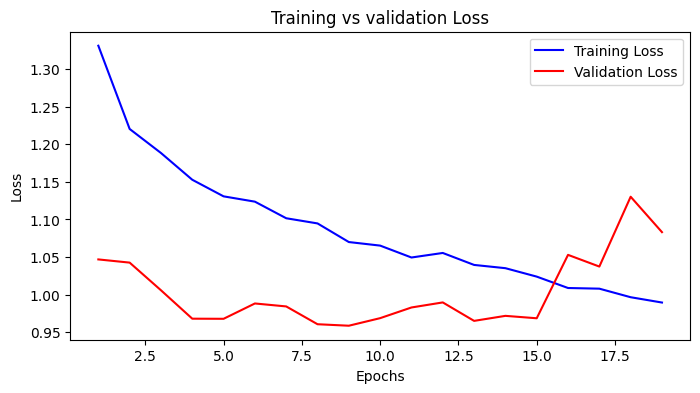

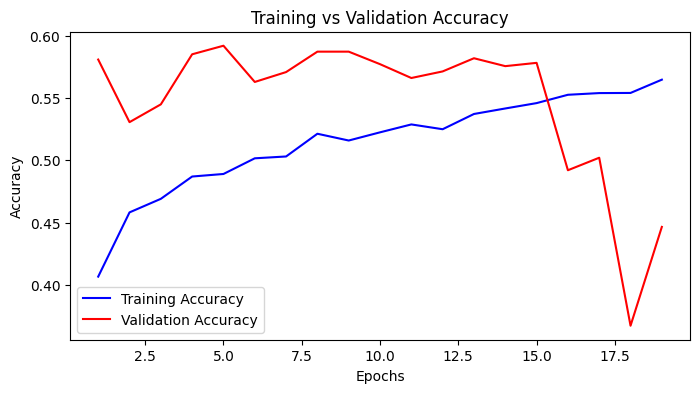

In [ ]:
#Plotting to training and validation to find out overfitting/underfitting
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

#Plot loss
plt.figure(figsize=(8,4))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs validation Loss')
plt.savefig(os.path.join(run_dir, 'loss.png'))
plt.show()
plt.close()

#Plot accuracy
plt.figure(figsize=(8, 4))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.savefig(os.path.join(run_dir, 'accuracy.png'))
plt.show()
plt.close()

7.1. Detailed Evaluation - confusion matrix, Precision, Recall, F1-score. Predictions on test dataset

In [ ]:
#Confusion matrix + metrics
y_true = []
y_pred = []

#Get predictions and true labels
for images, labels in test_dataset:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    # Convert one-hot encoded y_true back to single integer labels
    y_true.extend(np.argmax(labels.numpy(), axis=1))

#Confusion matrix

cm = confusion_matrix(y_true, y_pred)
print("\n Confusion Matrix: \n", cm)
np.save(os.path.join(run_dir, 'confusion_matrix.npy'), cm)

#Save classification report

class_names = ['authentic', 'copy-move', 'splicing']
report = classification_report(y_true, y_pred, target_names=class_names)

with open(os.path.join(run_dir, 'metrics.txt'), 'w') as f:
    f.write(report)
print("\nClassification Report:\n", report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7.2. Plot to confusion matrix for each classes

In [ ]:
'''from sklearn.metrics import multilabel_confusion_matrix
import tensorflow as tf # Import tensorflow for tf.data.Dataset and AUTOTUNE
import numpy as np # Import numpy for np.argmax

# Redefine necessary variables if they are not persistently available
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Recreate the test_dataset from X_test and y_test if they exist in kernel memory
# Assuming X_test and y_test are available from a previous cell execution (cell 95b1c077)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

y_true = []
y_pred = []

#Get predictions and true labels
for images, labels in test_dataset:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    # Convert one-hot encoded y_true back to single integer labels
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Get per-class confusion matrices
mcm = multilabel_confusion_matrix(y_true, y_pred)

class_names = ['authentic', 'copy-move', 'splicing']

for i, cm in enumerate(mcm):
    plt.figure()

    plt.imshow(cm, interpolation='nearest')
    plt.title(f"Confusion Matrix - {class_names[i]}")
    plt.colorbar()

    labels = ['Not ' + class_names[i], class_names[i]] # Make labels more specific
    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    # Add values + labels
    labels_matrix = [['TN', 'FP'], ['FN', 'TP']]

    for x in range(2):
        for y in range(2):
            plt.text(y, x, f"{labels_matrix[x][y]}\n{cm[x, y]}",
                     ha="center", va="center", color="white" if cm[x,y] > cm.max()/2 else "black") # Add color for better contrast

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()'''

'from sklearn.metrics import multilabel_confusion_matrix\nimport tensorflow as tf # Import tensorflow for tf.data.Dataset and AUTOTUNE\nimport numpy as np # Import numpy for np.argmax\n\n# Redefine necessary variables if they are not persistently available\nbatch_size = 32\nAUTOTUNE = tf.data.AUTOTUNE\n\n# Recreate the test_dataset from X_test and y_test if they exist in kernel memory\n# Assuming X_test and y_test are available from a previous cell execution (cell 95b1c077)\ntest_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))\ntest_dataset = test_dataset.batch(batch_size).prefetch(buffer_size=AUTOTUNE)\n\ny_true = []\ny_pred = []\n\n#Get predictions and true labels\nfor images, labels in test_dataset:\n    preds = model.predict(images)\n    preds = np.argmax(preds, axis=1)\n\n    y_pred.extend(preds)\n    # Convert one-hot encoded y_true back to single integer labels\n    y_true.extend(np.argmax(labels.numpy(), axis=1))\n\n# Get per-class confusion matrices\nmcm = multi

8. Confusion matrix + evaluation metrics per class

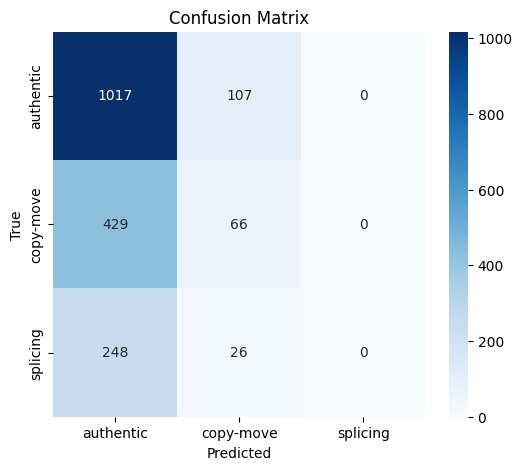


Classification Report:
               precision    recall  f1-score   support

   authentic       0.60      0.90      0.72      1124
   copy-move       0.33      0.13      0.19       495
    splicing       0.00      0.00      0.00       274

    accuracy                           0.57      1893
   macro avg       0.31      0.35      0.30      1893
weighted avg       0.44      0.57      0.48      1893


Per-Class Metrics Table:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,class,precision,recall,f1_score,support
0,authentic,0.600354,0.904804,0.721789,1124
1,copy-move,0.331658,0.133333,0.190202,495
2,splicing,0.000000,0.000000,0.000000,274


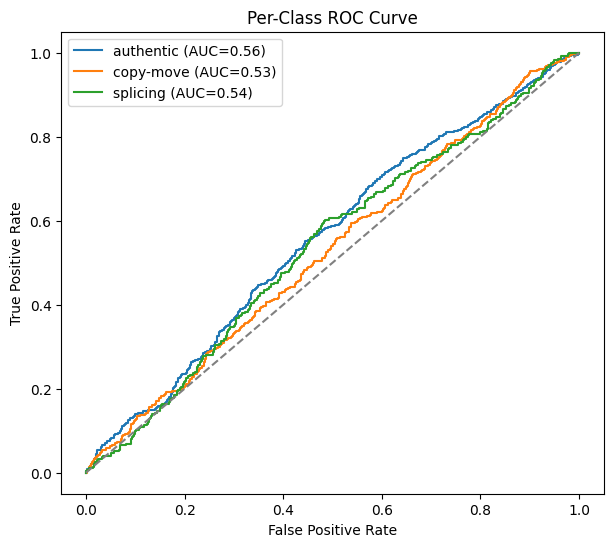

All evaluation results saved in: /content/drive/MyDrive/model_image/experiments/run_20260428_085942


In [ ]:
##### 8. EVALUATION + SAVING RESULTS (PER CLASS)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd



class_names = ['authentic', 'copy-move', 'splicing']

# =========================
# 8.1 COLLECT PREDICTIONS
# =========================
y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_prob.extend(probs)
    y_pred.extend(preds)
    y_true.extend(true)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================
# 8.2 CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# SAVE
plt.savefig(os.path.join(run_dir, "confusion_matrix.png"))
plt.show()

np.save(os.path.join(run_dir, "confusion_matrix.npy"), cm)

# =========================
# 8.3 CLASSIFICATION REPORT
# =========================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# SAVE AS CSV (clean table for thesis)
pd.DataFrame(report).transpose().to_csv(
    os.path.join(run_dir, "classification_report.csv")
)

# SAVE TEXT VERSION
text_report = classification_report(y_true, y_pred, target_names=class_names)
with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
    f.write(text_report)

print("\nClassification Report:\n", text_report)

# =========================
# 8.4 PER-CLASS METRICS TABLE
# =========================
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred
)

metrics_df = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

metrics_df.to_csv(os.path.join(run_dir, "per_class_metrics.csv"), index=False)
print("\nPer-Class Metrics Table:")
display(metrics_df)

# =========================
# 8.5 ROC CURVES (PER CLASS)
# =========================
y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Per-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# SAVE ROC
plt.savefig(os.path.join(run_dir, "roc_curve.png"))
plt.show()

# =========================
# 8.6 FINAL SUMMARY JSON
# =========================
results = {
    "test_accuracy": float(test_accuracy),
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}

with open(os.path.join(run_dir, "results.json"), "w") as f:
    json.dump(results, f, indent=4)

print("All evaluation results saved in:", run_dir)
